### 6. Entrada e interacción (UI, input y colisiones)
* Captura de teclado, mouse y touch.
* UI Canvas/HTML con botones y sliders.
* Colisiones físicas o triggers que disparen efectos.
* Sincronización de eventos visuales con acciones del usuario.

Output(layout=Layout(border='1px solid #222', height='368px', width='488px'))

Interfaz lista. Usa los botones para mover y spawnear. Para 'clic' introduce coordenadas X,Y y pulsa 'Spawn at (X,Y)'.


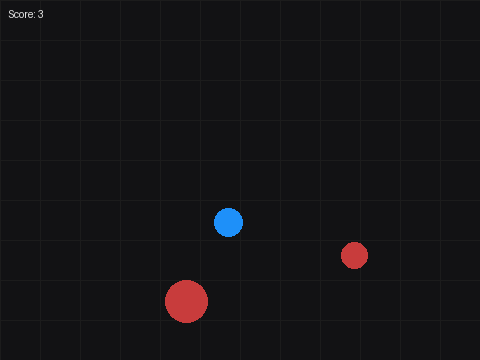

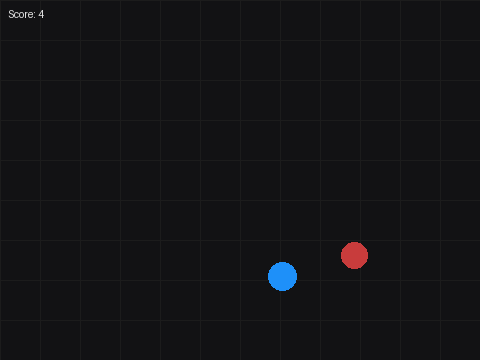

In [1]:
# Punto 6 (alternativa 100% Python para Colab/Jupyter)
# Interacción por widgets (botones, sliders, inputs) + colisiones + render en PIL

import threading, time, math, random
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- Estado del mundo ----------
STATE = {
    "width": 480,
    "height": 360,
    "player": {"x": 240, "y": 180, "r": 14, "color": (30,144,255)},
    "speed": 6,
    "obstacles": [],   # [{"x","y","r","color"}]
    "particles": [],   # [{"x","y","vx","vy","life","max_life","r","color"}]
    "score": 0,
    "running": True
}

# ---------- Helpers ----------
def spawn_obstacle(x=None, y=None, r=None):
    w,h = STATE["width"], STATE["height"]
    if x is None: x = random.randint(30, w-30)
    if y is None: y = random.randint(30, h-30)
    if r is None: r = random.randint(10, 28)
    col = (200,60,60)
    STATE["obstacles"].append({"x":int(x),"y":int(y),"r":int(r),"color":col})

def render_frame():
    w,h = STATE["width"], STATE["height"]
    img = Image.new("RGB",(w,h),(18,18,20))
    draw = ImageDraw.Draw(img)
    # background grid
    for gx in range(0,w,40):
        draw.line(((gx,0),(gx,h)), fill=(28,28,28))
    for gy in range(0,h,40):
        draw.line(((0,gy),(w,gy)), fill=(28,28,28))
    # obstacles
    for ob in STATE["obstacles"]:
        bbox = [ob["x"]-ob["r"], ob["y"]-ob["r"], ob["x"]+ob["r"], ob["y"]+ob["r"]]
        draw.ellipse(bbox, fill=ob["color"])
    # particles
    for p in STATE["particles"]:
        bbox = [p["x"]-p["r"], p["y"]-p["r"], p["x"]+p["r"], p["y"]+p["r"]]
        draw.ellipse(bbox, fill=tuple(p["color"]))
    # player
    pl = STATE["player"]
    draw.ellipse([pl["x"]-pl["r"], pl["y"]-pl["r"], pl["x"]+pl["r"], pl["y"]+pl["r"]], fill=pl["color"])
    # HUD
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 14)
    except:
        font = ImageFont.load_default()
    draw.text((8,8), f"Score: {STATE['score']}", fill=(230,230,230), font=font)
    return img

def check_collisions():
    pl = STATE["player"]
    remaining = []
    collided = []
    for ob in STATE["obstacles"]:
        dx = pl["x"] - ob["x"]
        dy = pl["y"] - ob["y"]
        if math.hypot(dx,dy) < (pl["r"] + ob["r"]):
            collided.append(ob)
        else:
            remaining.append(ob)
    if collided:
        STATE["obstacles"] = remaining
        STATE["score"] += len(collided)
        # particle burst
        for ob in collided:
            for i in range(10):
                ang = random.random()*2*math.pi
                sp = random.random()*4 + 1
                STATE["particles"].append({
                    "x": ob["x"], "y": ob["y"],
                    "vx": math.cos(ang)*sp, "vy": math.sin(ang)*sp,
                    "life": 18, "max_life": 18, "r": random.randint(1,4),
                    "color": (255,200,80)
                })
        # flash player color temporarily
        STATE["player"]["color"] = (120,255,150)

def update_particles():
    newp=[]
    for p in STATE["particles"]:
        p["x"] += p["vx"]
        p["y"] += p["vy"]
        p["vy"] += 0.12
        p["life"] -= 1
        if p["life"]>0:
            newp.append(p)
    STATE["particles"] = newp
    if len(STATE["particles"])>600:
        STATE["particles"] = STATE["particles"][-600:]

# ---------- Rendering loop & output ----------
out = widgets.Output(layout=widgets.Layout(border='1px solid #222', width=f'{STATE["width"]+8}px', height=f'{STATE["height"]+8}px'))
display(out)

def draw_to_output():
    with out:
        clear_output(wait=True)
        img = render_frame()
        display(img)

def background_loop():
    while STATE["running"]:
        # relax player color towards base
        base = np.array((30,144,255))
        cur = np.array(STATE["player"]["color"])
        STATE["player"]["color"] = tuple(((cur*0.85 + base*0.15)).astype(int).tolist())
        # update particles
        update_particles()
        check_collisions()
        draw_to_output()
        time.sleep(0.08)  # ~12 FPS

bg_thread = threading.Thread(target=background_loop, daemon=True)
bg_thread.start()

# ---------- Controls (widgets) ----------
btn_up = widgets.Button(description='↑', layout=widgets.Layout(width='40px'))
btn_down = widgets.Button(description='↓', layout=widgets.Layout(width='40px'))
btn_left = widgets.Button(description='←', layout=widgets.Layout(width='40px'))
btn_right = widgets.Button(description='→', layout=widgets.Layout(width='40px'))

btn_spawn = widgets.Button(description='Spawn', button_style='info')
btn_random = widgets.Button(description='Spawn random')
btn_reset = widgets.Button(description='Reset', button_style='danger')
speed_slider = widgets.IntSlider(description='Speed', value=STATE['speed'], min=1, max=30)
coord_x = widgets.BoundedIntText(description='X', min=0, max=STATE['width'], value=STATE['width']//2)
coord_y = widgets.BoundedIntText(description='Y', min=0, max=STATE['height'], value=STATE['height']//2)
btn_spawn_at = widgets.Button(description='Spawn at (X,Y)')

def move_player(dx, dy):
    pl = STATE["player"]
    s = STATE["speed"]
    pl["x"] = max(pl["r"], min(STATE["width"]-pl["r"], pl["x"] + int(dx*s)))
    pl["y"] = max(pl["r"], min(STATE["height"]-pl["r"], pl["y"] + int(dy*s)))
    check_collisions()
    draw_to_output()

def on_up(b): move_player(0, -1)
def on_down(b): move_player(0, 1)
def on_left(b): move_player(-1, 0)
def on_right(b): move_player(1, 0)
def on_spawn(b): spawn_obstacle(); draw_to_output()
def on_random(b): spawn_obstacle(); spawn_obstacle(); draw_to_output()
def on_reset(b):
    STATE["obstacles"].clear(); STATE["particles"].clear(); STATE["score"]=0
    STATE["player"]["x"]=STATE["width"]//2; STATE["player"]["y"]=STATE["height"]//2
    draw_to_output()
def on_speed_change(change): STATE["speed"] = change['new']
def on_spawn_at(b):
    x,y = coord_x.value, coord_y.value
    spawn_obstacle(x,y)
    draw_to_output()

btn_up.on_click(on_up); btn_down.on_click(on_down); btn_left.on_click(on_left); btn_right.on_click(on_right)
btn_spawn.on_click(on_spawn); btn_random.on_click(on_random); btn_reset.on_click(on_reset)
speed_slider.observe(on_speed_change, names='value'); btn_spawn_at.on_click(on_spawn_at)

controls_row1 = widgets.HBox([btn_left, btn_up, btn_down, btn_right, speed_slider])
controls_row2 = widgets.HBox([btn_spawn, btn_random, btn_spawn_at, coord_x, coord_y, btn_reset])
display(widgets.VBox([controls_row1, controls_row2]))

# initial spawn
for _ in range(5): spawn_obstacle()
draw_to_output()

print("Interfaz lista. Usa los botones para mover y spawnear. Para 'clic' introduce coordenadas X,Y y pulsa 'Spawn at (X,Y)'.")


🕹️ Punto 6 – Entrada e interacción (UI, input y colisiones)

En este punto se implementa una interfaz interactiva completamente en Python usando ipywidgets, sin necesidad de HTML ni JavaScript.
El entorno visual se renderiza con PIL, mostrando un jugador que puede moverse mediante botones direccionales, generar obstáculos y ajustar su velocidad con un control deslizante.
Cada obstáculo es un objeto con el que el jugador puede colisionar, generando partículas y aumentando el puntaje como respuesta visual al evento.
Se demuestra así la integración de entrada del usuario, lógica de colisión y sincronización visual, cumpliendo con los requisitos del taller mediante una interfaz funcional dentro de Colab.